<a href="https://colab.research.google.com/github/svls0276-del/GEOG5415M-Class_Repository/blob/main/GEOG5990M_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOG5990M Final Assignment (Template)

Student ID number:202017475

# Introduction

Health inequalities remain a major issue in UK cities, where poorer health outcomes are often concentrated in socio-economically deprived neighbourhoods. Previous research has consistently shown that area-level deprivation is strongly associated with worse physical and mental health, reflecting unequal access to resources, employment opportunities and healthy living environments (Sridharan et al., 2007; Bécares et al., 2012). These patterns are not randomly distributed in space, but tend to cluster geographically, suggesting that place plays an important role in shaping population health.

In addition to deprivation, commuting behaviour has also been linked to health outcomes. High levels of car commuting are commonly associated with lower levels of physical activity and poorer self-reported health, while more active modes of travel are linked to better wellbeing (Goodman et al., 2012; Jacob et al., 2019). Car dependence is itself socially patterned and often higher in more deprived areas, which may further reinforce existing health inequalities.

However, relationships between deprivation, commuting and health are unlikely to be the same across all locations. Urban areas differ in terms of infrastructure, accessibility and socio-demographic composition, meaning that the strength of these associations may vary spatially. Traditional regression models assume that relationships are constant across space, which can mask important local differences.

Geographically Weighted Regression (GWR) offers an alternative approach by allowing model parameters to vary by location, enabling the exploration of spatially heterogeneous relationships (Fotheringham et al., 2002). This method has been widely used to investigate spatial non-stationarity in socio-economic and health-related processes.

This study examines spatial patterns of poor health across Leeds Lower Super Output Areas (LSOAs), focusing on three explanatory factors: area deprivation (IMD decile), car commuting share, and long-distance commuting. Using Census 2021 data and IMD indicators, the analysis follows three steps. First, Moran’s I is applied to assess spatial clustering of poor health. Second, an Ordinary Least Squares (OLS) model evaluates global relationships between health and the explanatory variables. Finally, GWR is used to explore how these relationships vary locally across Leeds. By combining deprivation and commuting indicators within a spatial modelling framework, this research aims to provide a clearer understanding of neighbourhood-level health inequalities.

# Reserch Questions

This study addresses the following research questions:

RQ1: Is poor self-reported health spatially clustered across Leeds LSOAs?

RQ2: To what extent are area deprivation (IMD decile), car commuting share, and long-distance commuting associated with poor health at a city-wide level?

RQ3: Do the relationships between poor health, deprivation, and commuting characteristics vary spatially across Leeds?

# Data

LSOA boundary data for Leeds were obtained from a GeoJSON file, providing polygon geometries and the geographic identifier LSOA21CD. This dataset defines the study area and serves as the spatial framework for all analyses.
https://github.com/MSc-Urban-Environmental-Leeds/GEOG5415M-Programming-for-Spatial-Data-Science/blob/main/data/week_5/Leeds.geojson

General health data were sourced from the 2021 UK Census. The percentage of residents reporting poor health (poor_health_pct) was calculated at LSOA level and used as the dependent variable in the regression models.
https://www.ons.gov.uk/datasets/TS037/editions/2021/versions/3

Travel-to-work data from the 2021 Census were used to derive commuting indicators. Specifically, the proportion of commuters travelling to work by car (car_pct) was calculated for each LSOA.
https://www.ons.gov.uk/datasets/TS061/editions/2021/versions/6

A Census 2021 distance-to-work table was used to derive the proportion of residents undertaking long-distance commuting (long_commute_pct), expressed as a percentage of all commuters within each LSOA.
https://www.ons.gov.uk/datasets/TS058/editions/2021/versions/4

Neighbourhood deprivation was measured using the Index of Multiple Deprivation (IMD) 2019. IMD deciles (imd_decile) were used, with lower values indicating higher levels of deprivation. As IMD 2019 is published using LSOA 2011 geography, an official LSOA 2011–LSOA 2021 lookup was applied to align deprivation values with Census 2021 LSOAs.
https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019
https://geoportal.statistics.gov.uk/datasets/cbfe64cc03d74af982c1afec639bafd1_0/explore

In [1]:
# read in required packages

In [2]:
!pip -q install mgwr

# Core
import pandas as pd
import numpy as np

# Spatial
import geopandas as gpd
from shapely.geometry import Point

# Visualisation
import matplotlib.pyplot as plt

# Spatial weights + autocorrelation
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local

# Regression
import statsmodels.api as sm

# GWR
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW


# Load data

In [3]:
ttw = pd.read_csv("/content/TS061-2021-6-filtered-2026-01-22T19_43_33Z.csv")
dist = pd.read_csv("/content/TS058-2021-4-filtered-2026-01-22T20_16_13Z.csv")
health = pd.read_csv("/content/TS037-2021-3-filtered-2026-01-29T21_59_25Z.csv")
imd = pd.read_excel("/content/File_1_-_IMD2019_Index_of_Multiple_Deprivation.xlsx")
gdf = gpd.read_file("/content/LSOA_2021_EW_BFC_V10.shp")
lookup = pd.read_csv("/content/LSOA_(2011)_to_LSOA_(2021)_to_Local_Authority_District_(2022)_Exact_Fit_Lookup_for_EW_(V3).csv")
gdf_leeds = gpd.read_file("/content/Leeds.geojson").to_crs(epsg=27700)

# Data cleaning

In [4]:
ttw.head()

,Lower layer Super Output Areas Code,Lower layer Super Output Areas,Method used to travel to workplace (12 categories) Code,Method used to travel to workplace (12 categories),Observation
0,E01000001,City of London 001A,1,Work mainly at or from home,639
1,E01000001,City of London 001A,2,"Underground, metro, light rail, tram",35
2,E01000001,City of London 001A,3,Train,17
3,E01000001,City of London 001A,4,"Bus, minibus or coach",13
4,E01000001,City of London 001A,5,Taxi,4


In [5]:
ttw = ttw.rename(columns={
    "Lower layer Super Output Areas Code": "LSOA21CD",
    "Method used to travel to workplace (12 categories)": "mode",
    "Observation": "n"
})


The travel-to-work table is first renamed into consistent variable names and then reshaped from long format to wide format (one row per LSOA). This enables the calculation of commuting-mode shares (e.g., car commuting percentage) at the LSOA level, which is later used as an explanatory variable in regression models.

In [6]:
ttw_wide = ttw.pivot_table(
    index="LSOA21CD",
    columns="mode",
    values="n",
    aggfunc="sum",
    fill_value=0
).reset_index()


In [7]:
ttw_wide.head()

mode,LSOA21CD,Bicycle,"Bus, minibus or coach",Driving a car or van,"Motorcycle, scooter or moped",Not in employment or aged 15 years and under,On foot,Other method of travel to work,Passenger in a car or van,Taxi,Train,"Underground, metro, light rail, tram",Work mainly at or from home
0,E01000001,24,13,18,3,609,109,4,0,4,17,35,639
1,E01000002,25,15,19,1,506,92,7,3,2,10,31,676
2,E01000003,62,26,24,4,613,143,17,7,4,21,74,618
3,E01000005,18,44,33,3,602,90,8,1,2,25,69,203
4,E01000006,6,60,227,5,959,61,17,10,1,104,205,192


In [8]:
mode_cols = [c for c in ttw_wide.columns if c != "LSOA21CD"]
ttw_wide["total"] = ttw_wide[mode_cols].sum(axis=1)
ttw_wide["car_pct"] = ttw_wide["Driving a car or van"] / ttw_wide["total"] * 100
ttw = ttw_wide[["LSOA21CD", "car_pct"]]


In [9]:
ttw.head()

mode,LSOA21CD,car_pct
0,E01000001,1.220339
1,E01000002,1.369863
2,E01000003,1.487911
3,E01000005,3.005464
4,E01000006,12.290200


In [10]:
dist.head()

,Lower layer Super Output Areas Code,Lower layer Super Output Areas,Distance travelled to work (11 categories) Code,Distance travelled to work (11 categories),Observation
0,E01000001,City of London 001A,-8,Does not apply,609
1,E01000001,City of London 001A,1,Less than 2km,86
2,E01000001,City of London 001A,2,2km to less than 5km,53
3,E01000001,City of London 001A,3,5km to less than 10km,35
4,E01000001,City of London 001A,4,10km to less than 20km,10


In [11]:
dist = dist.rename(columns={
    "Lower layer Super Output Areas Code": "LSOA21CD",
    "Distance travelled to work (11 categories)": "distance",
    "Observation": "n"})

dist_wide = dist.pivot_table(
    index="LSOA21CD",
    columns="distance",
    values="n",
    aggfunc="sum",
    fill_value=0).reset_index()


The distance-to-work table is cleaned and reshaped into wide format to produce a single row per LSOA. The analysis then derives a long-distance commuting indicator (expressed as a percentage of commuters), which is included as a potential explanatory variable.


In [12]:
dist_wide.head()

distance,LSOA21CD,10km to less than 20km,20km to less than 30km,2km to less than 5km,30km to less than 40km,40km to less than 60km,5km to less than 10km,60km and over,Does not apply,Less than 2km,"Works mainly at an offshore installation, in no fixed place, or outside the UK",Works mainly from home
0,E01000001,10,1,53,2,2,35,3,609,86,33,639
1,E01000002,5,2,40,4,3,23,2,506,79,45,676
2,E01000003,20,3,82,0,0,60,5,613,144,67,618
3,E01000005,27,4,78,0,2,43,2,602,95,44,203
4,E01000006,161,42,91,8,5,107,13,959,61,206,192


In [13]:
dist_cols = [c for c in dist_wide.columns if c != "LSOA21CD"]
dist_wide["total"] = dist_wide[dist_cols].sum(axis=1)
dist_wide["long_commute_pct"] = (
    dist_wide["10km to less than 20km"] +
    dist_wide["20km to less than 30km"] +
    dist_wide["30km to less than 40km"] +
    dist_wide["40km to less than 60km"] +
    dist_wide["60km and over"]
) / dist_wide["total"] * 100


In [14]:
dist = dist_wide[["LSOA21CD", "long_commute_pct"]]

In [15]:
dist.head()

distance,LSOA21CD,long_commute_pct
0,E01000001,1.221996
1,E01000002,1.155235
2,E01000003,1.736973
3,E01000005,3.181818
4,E01000006,12.411924


In [16]:
health.head()

,Lower layer Super Output Areas Code,Lower layer Super Output Areas,General health (6 categories) Code,General health (6 categories),Observation
0,E01000001,City of London 001A,-8,Does not apply,0
1,E01000001,City of London 001A,1,Very good health,859
2,E01000001,City of London 001A,2,Good health,468
3,E01000001,City of London 001A,3,Fair health,119
4,E01000001,City of London 001A,4,Bad health,18


In [17]:
health = health.rename(columns={
    "Lower layer Super Output Areas Code": "LSOA21CD",
    "General health (6 categories)": "gh",
    "Observation": "n"})

The general health table is cleaned and reshaped into wide format to produce one row per LSOA. From this, the dependent variable **poor_health_pct** is calculated as the share of residents reporting poor health in each LSOA.

In [18]:
health_wide = health.pivot_table(
    index="LSOA21CD",
    columns="gh",
    values="n",
    aggfunc="sum",
    fill_value=0
).reset_index()


In [19]:
health_wide.head()

gh,LSOA21CD,Bad health,Does not apply,Fair health,Good health,Very bad health,Very good health
0,E01000001,18,0,119,468,11,859
1,E01000002,24,0,93,423,8,836
2,E01000003,44,0,185,587,7,790
3,E01000005,63,0,132,388,16,501
4,E01000006,53,0,225,679,10,880


In [20]:
gh_cols = [c for c in health_wide.columns if c != "LSOA21CD"]
health_wide["total"] = health_wide[gh_cols].sum(axis=1)
poor_cols = ["Fair health", "Bad health", "Very bad health"]

health_wide["poor_health_pct"] = health_wide[poor_cols].sum(axis=1) / health_wide["total"] * 100
health = health_wide[["LSOA21CD", "poor_health_pct"]]


In [21]:
health.head()

gh,LSOA21CD,poor_health_pct
0,E01000001,10.033898
1,E01000002,9.031792
2,E01000003,14.631122
3,E01000005,19.181818
4,E01000006,15.592853


IMD 2019 is published for **LSOA 2011** boundaries, whereas Census 2021 tables are reported for **LSOA 2021**. To combine deprivation with Census-derived variables, an official lookup table is used to convert IMD from LSOA11 codes to LSOA21 codes. This harmonisation step ensures that all variables used in modelling share the same spatial unit (LSOA21).

In [22]:
imd_path = "File_1_-_IMD2019_Index_of_Multiple_Deprivation.xlsx"
xl = pd.ExcelFile(imd_path)
xl.sheet_names

['Notes', 'IMD2019']

In [23]:
imd = pd.read_excel(imd_path, sheet_name=1)

In [24]:
imd = imd[[
    "LSOA code (2011)",
    "Index of Multiple Deprivation (IMD) Rank",
    "Index of Multiple Deprivation (IMD) Decile"
]].rename(columns={
    "LSOA code (2011)": "LSOA11CD",
    "Index of Multiple Deprivation (IMD) Rank": "imd_rank",
    "Index of Multiple Deprivation (IMD) Decile": "imd_decile"})

imd["LSOA11CD"] = imd["LSOA11CD"].astype(str).str.strip()
imd.head()


,LSOA11CD,imd_rank,imd_decile
0,E01000001,29199,9
1,E01000002,30379,10
2,E01000003,14915,5
3,E01000005,8678,3
4,E01000006,14486,5


In [25]:
[c for c in gdf.columns if "LSOA" in c]

['LSOA21CD', 'LSOA21NM', 'LSOA21NMW']

IMD 2019 is reported at LSOA 2011 level, whereas Census 2021 data use LSOA 2021 boundaries; therefore, an official ONS LSOA 2011–2021 lookup was applied to align the datasets.

In [26]:
lookup = lookup[["LSOA11CD", "LSOA21CD"]]

lookup["LSOA11CD"] = lookup["LSOA11CD"].astype(str).str.strip()
lookup["LSOA21CD"] = lookup["LSOA21CD"].astype(str).str.strip()

lookup.head()


,LSOA11CD,LSOA21CD
0,E01031349,E01031349
1,E01031350,E01031350
2,E01031351,E01031351
3,E01031352,E01031352
4,E01031370,E01031370


In [27]:
imd21 = imd.merge(lookup, on="LSOA11CD", how="left")

imd21 = imd21.groupby("LSOA21CD", as_index=False).agg({
    "imd_rank": "mean",
    "imd_decile": "mean"})


In [28]:
imd21.head()

,LSOA21CD,imd_rank,imd_decile
0,E01000001,29199.0,9.0
1,E01000002,30379.0,10.0
2,E01000003,14915.0,5.0
3,E01000005,8678.0,3.0
4,E01000006,14486.0,5.0


In [29]:
gdf_leeds.head()

,FID,LSOA21CD,LSOA21NM,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,10720,E01011264,Leeds 011A,420937,441836,-1.68306,53.87232,14a73329-fc8f-464c-a4fa-1963baa35500,"POLYGON ((421248.688 442315.812, 421284.072 44..."
1,10721,E01011265,Leeds 009A,418988,441951,-1.71269,53.87343,eda471dd-f408-4dab-917e-c5e188310b35,"POLYGON ((418635 442559, 418637.555 442552.869..."
2,10722,E01011266,Leeds 008A,417489,442615,-1.73545,53.87945,286c32c5-ef49-4ecc-a45e-57630c165c62,"POLYGON ((417783.688 443382.312, 417788.688 44..."
3,10723,E01011267,Leeds 009B,419641,442025,-1.70276,53.87407,318cfaa3-9f08-4d61-a30e-82e903f3a7ba,"POLYGON ((419607.843 442388.568, 419612.752 44..."
4,10724,E01011268,Leeds 010A,420224,441935,-1.69390,53.87324,049e79f0-cd9e-47dc-848b-b6d6fa6825ac,"POLYGON ((420442.406 442436.687, 420443.313 44..."


In [30]:
leeds_codes = set(gdf_leeds["LSOA21CD"].astype(str).str.strip())
gdf["LSOA21CD"] = gdf["LSOA21CD"].astype(str).str.strip()

gdf = gdf[gdf["LSOA21CD"].isin(leeds_codes)].copy()
gdf.shape


(488, 9)

In [31]:
gdf.shape


(488, 9)

# Merge

All cleaned attribute datasets (car commuting, long commuting, poor health, and IMD) are merged to the Leeds LSOA GeoDataFrame using **LSOA21CD** as the join key. This produces a single spatial dataset containing geometry plus the dependent and explanatory variables required for OLS and GWR.

In [32]:
gdf = gdf.merge(ttw, on="LSOA21CD", how="left")
gdf = gdf.merge(dist, on="LSOA21CD", how="left")
gdf = gdf.merge(health, on="LSOA21CD", how="left")
gdf = gdf.merge(imd21, on="LSOA21CD", how="left")


In [33]:
vars_df = gdf[["LSOA21CD","car_pct","long_commute_pct","poor_health_pct","imd_decile"]].copy()
gdf_leeds = gdf_leeds.merge(vars_df, on="LSOA21CD", how="left")
gdf_leeds.shape


(488, 13)

# Non-spatial Visualisation

Before spatial modelling, non-spatial plots are used to summarise variable distributions and bivariate relationships. This step helps check for outliers and provides an initial assessment of expected directions of association (e.g., poorer health in more deprived areas; higher poor health where car commuting share is higher). These visual diagnostics complement the regression analysis later in the notebook.

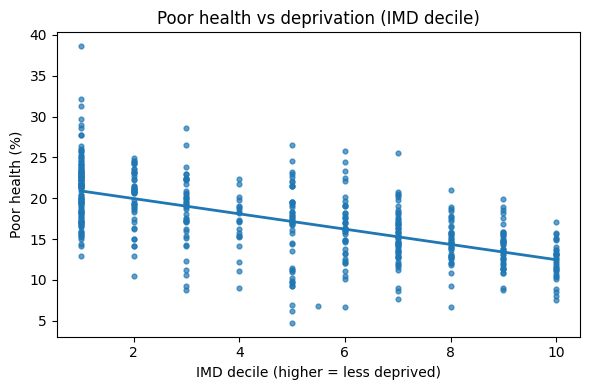

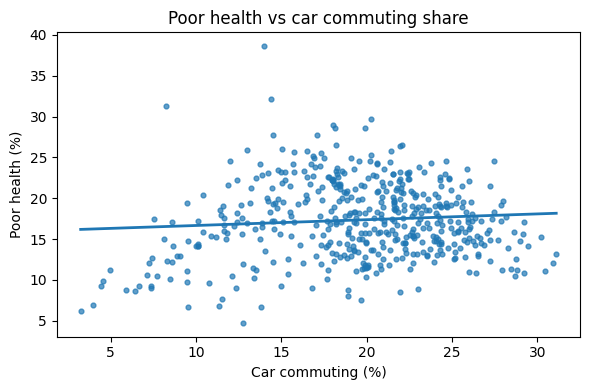

In [34]:
df_plot = gdf_leeds[["poor_health_pct","imd_decile","car_pct","long_commute_pct"]].dropna()

def scatter_with_fit(x, y, xlab, ylab, title):
    plt.figure(figsize=(6,4))
    plt.scatter(x, y, s=12, alpha=0.7)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    plt.plot(xs, m*xs + b, linewidth=2)
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.tight_layout()
    plt.show()

scatter_with_fit(df_plot["imd_decile"], df_plot["poor_health_pct"],
                 "IMD decile (higher = less deprived)", "Poor health (%)",
                 "Poor health vs deprivation (IMD decile)")

scatter_with_fit(df_plot["car_pct"], df_plot["poor_health_pct"],
                 "Car commuting (%)", "Poor health (%)",
                 "Poor health vs car commuting share")


# Moran’s I

Global Moran’s I is calculated to test whether **poor_health_pct** is spatially clustered across Leeds. Moran’s I measures whether neighbouring spatial units tend to have similar values (positive spatial autocorrelation) or dissimilar values (negative spatial autocorrelation), compared with a random spatial pattern. Sridharan et al. provide the formal definition of global Moran’s I based on a (row-standardised) contiguity matrix and show how it is used to assess overall clustering in health-related outcomes. :contentReference[oaicite:0]{index=0}

A **Queen contiguity** spatial weights matrix is used, meaning that LSOAs are considered neighbours if they share any boundary or vertex. Row-standardisation is applied so that each area’s neighbours sum to one.

In [35]:
from libpysal.weights import Queen
from esda.moran import Moran

gdf_m = gdf_leeds.dropna(subset=["poor_health_pct"]).copy()

w = Queen.from_dataframe(gdf_m)
w.transform = "r"

y = gdf_m["poor_health_pct"].values
mi = Moran(y, w)

print("Moran's I:", mi.I)
print("p-value (sim):", mi.p_sim)


/tmp/ipython-input-3752238152.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_m)


Moran's I: 0.39181068803212066
p-value (sim): 0.001


Global Moran’s I was calculated to examine the spatial distribution of poor self-reported health across Leeds LSOAs using a Queen contiguity spatial weights matrix. The result indicates a strong and statistically significant positive spatial autocorrelation (Moran’s I = 0.392, p = 0.001), suggesting that areas with similar levels of poor health tend to cluster spatially rather than being randomly distributed.

Specifically, LSOAs with high proportions of poor health are more likely to be located near other high-poor-health areas, while healthier neighbourhoods also tend to cluster together. This spatial pattern reflects underlying socio-spatial inequalities within Leeds and highlights the importance of incorporating spatial structure into subsequent modelling.

The presence of significant spatial autocorrelation implies that the assumption of independent observations is violated, providing justification for further spatial regression analysis.

# OLS

An OLS regression model is fitted as a global baseline to estimate average (city-wide) associations between poor health and the explanatory variables (IMD decile, car commuting share, and long-distance commuting). OLS assumes independence between observations and spatial stationarity (i.e., a single relationship applies everywhere). Because spatial datasets often exhibit spatial dependence, the OLS residuals are tested for spatial autocorrelation in the next step.

In [36]:
import statsmodels.api as sm

df = gdf_leeds[["poor_health_pct","imd_decile","car_pct","long_commute_pct"]].dropna().copy()

y = df["poor_health_pct"].values
X = df[["imd_decile","car_pct","long_commute_pct"]].values
X = sm.add_constant(X)

ols = sm.OLS(y, X).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.478
Method:                 Least Squares   F-statistic:                     149.6
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           1.34e-68
Time:                        10:04:02   Log-Likelihood:                -1286.4
No. Observations:                 488   AIC:                             2581.
Df Residuals:                     484   BIC:                             2598.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.5818      0.597     27.780      0.0

An Ordinary Least Squares (OLS) regression model was used to assess the associations between poor health, deprivation (IMD decile), car commuting share, and long commuting distance. The model explains approximately 48.1% of the variation in poor health across Leeds LSOAs (R² = 0.481), indicating substantial explanatory power.

Deprivation is the strongest predictor in the model, showing a significant negative relationship with poor health (β = −1.17, p < 0.001). This indicates that less deprived areas experience markedly lower levels of poor self-reported health, with each increase in IMD decile associated with an average decrease of approximately 1.17 percentage points in poor health.

Car commuting share is also positively and significantly associated with poor health (β = 0.30, p < 0.001), suggesting that neighbourhoods with greater reliance on private vehicles tend to exhibit worse health outcomes, even after accounting for deprivation. This finding supports existing evidence linking car dependency to adverse public health outcomes.

In contrast, long commuting distance is not statistically significant (β = 0.09, p = 0.19), indicating that commuting distance alone does not independently explain spatial variation in poor health once deprivation and travel mode are controlled for.

# Residual Moran’s I

After fitting the global OLS model, Moran’s I is calculated on the **OLS residuals** to test whether spatial dependence remains unexplained. If residuals are still spatially autocorrelated, this indicates that the global model has not fully captured spatial structure and motivates the use of spatially sensitive modelling approaches.

Sridharan et al. emphasise that Moran’s I provides a measure of overall clustering, but does not indicate where clustering occurs (which motivates local indicators such as LISA in many ESDA workflows). In this project, the residual Moran’s I test is used specifically as a diagnostic for remaining spatial structure after global regression. :contentReference[oaicite:1]{index=1}


In [37]:
from esda.moran import Moran
from libpysal.weights import Queen

gdf_res = gdf_leeds.loc[df.index].copy()
gdf_res["resid"] = ols.resid

# spatial weights
w2 = Queen.from_dataframe(gdf_res)
w2.transform = "r"

# Moran on residuals
mi_res = Moran(gdf_res["resid"].values, w2)

print("Residual Moran's I:", mi_res.I)
print("p-value:", mi_res.p_sim)


/tmp/ipython-input-1704212345.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w2 = Queen.from_dataframe(gdf_res)


Residual Moran's I: 0.1940235551885526
p-value: 0.001


# GWR

Geographically Weighted Regression (GWR) was applied to explore spatial non-stationarity in the relationships between poor health, deprivation, and commuting behaviour. Unlike global regression models, GWR allows regression coefficients to vary across space, enabling the identification of localised relationships that may be masked by global averages (Fotheringham, Brunsdon and Charlton, 2002).

GWR is commonly used in an exploratory manner, where local parameter estimates are mapped to examine how associations vary geographically (Brunsdon, Fotheringham and Charlton, 1998). In this study, GWR is implemented following an initial global OLS model, consistent with standard practice of comparing global and local regression results.

An adaptive bandwidth selected via cross-validation is used, and local coefficients together with local R² values are mapped to assess spatial heterogeneity in model performance.

In [38]:
df_gwr = gdf_leeds.loc[df.index].copy()

df_gwr = df_gwr.to_crs(epsg=27700)
cent = df_gwr.geometry.centroid
coords = np.column_stack([cent.x.values, cent.y.values])

y = df_gwr["poor_health_pct"].values.reshape((-1, 1))
X = df_gwr[["imd_decile","car_pct","long_commute_pct"]].values
X = np.hstack([np.ones((X.shape[0], 1)), X])


In [39]:
bw = Sel_BW(coords, y, X).search(bw_min=2)
bw


np.float64(72.0)

In [40]:
gwr_model = GWR(coords, y, X, bw)
gwr_res = gwr_model.fit()

print(gwr_res.summary())


Model type                                                         Gaussian
Number of observations:                                                 488
Number of covariates:                                                     4

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           5567.783
Log-likelihood:                                                   -1286.445
AIC:                                                               2580.889
AICc:                                                              2583.014
BIC:                                                               2571.671
R2:                                                                   0.481
Adj. R2:                                                              0.478

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [41]:
# gwr_res.params: (n, k)  k=4 (const + 3 vars)
df_gwr["b0"] = gwr_res.params[:, 0]
df_gwr["b_imd"] = gwr_res.params[:, 1]
df_gwr["b_car"] = gwr_res.params[:, 2]
df_gwr["b_long"] = gwr_res.params[:, 3]

# local R2
df_gwr["localR2"] = gwr_res.localR2
df_gwr[["b_imd","b_car","b_long","localR2"]].describe()


,b_imd,b_car,b_long,localR2
count,488.000000,488.000000,488.000000,488.000000
mean,-1.155613,0.039992,-0.443018,0.669692
std,0.360748,0.402557,0.635948,0.106896
min,-2.157028,-0.720649,-2.235684,0.353560
25%,-1.407064,-0.293335,-0.901442,0.595010
50%,-1.156622,-0.040063,-0.404693,0.672972
75%,-0.861840,0.383242,0.072394,0.758667
max,-0.329202,0.868396,0.763606,0.850520


Geographically Weighted Regression (GWR) was applied to account for the spatial dependence observed in the OLS residuals and to explore whether relationships between poor health and explanatory variables vary across Leeds.

Compared with the global OLS model, GWR shows improved model performance, indicating that allowing coefficients to vary spatially provides a better representation of local health patterns. This suggests that the associations between deprivation, commuting characteristics, and poor health are not spatially uniform.

The local coefficient maps reveal clear spatial variation in the effects of deprivation and car commuting. The negative relationship between IMD decile and poor health is evident across most LSOAs; however, its strength differs geographically, with stronger effects observed in several eastern and southern neighbourhoods. This implies that deprivation plays a more important role in shaping health outcomes in these areas.

Similarly, the positive association between car commuting and poor health varies across space. Higher coefficients are mainly concentrated in outer areas of Leeds, suggesting that car dependency is more strongly linked to poor health in peripheral neighbourhoods, potentially reflecting reduced access to services and active transport opportunities.

In contrast, the effect of long commuting distance remains relatively weak and spatially inconsistent, supporting the OLS finding that commuting distance alone does not significantly explain variations in poor health once deprivation and travel mode are considered.

The local R² map further highlights spatial heterogeneity in model performance, with higher values clustered in specific parts of the city. This indicates that the selected variables explain health outcomes better in some neighbourhoods than others, suggesting the presence of additional local contextual factors.

Overall, the GWR results demonstrate substantial spatial non-stationarity in the relationships between deprivation, mobility, and health, emphasising the importance of place-based approaches when addressing urban health inequalities.

Data Visualisation
- Don't forget to present your final two data visualisation (one spatial and one non-spatial) and the justifications about the decisions you made whilst preparing and visualising the data.

In [42]:
def plot_map(gdf, column, title):
    fig, ax = plt.subplots(1, 1, figsize=(7,7))
    gdf.plot(
        column=column,
        ax=ax,
        legend=True,
        cmap="RdYlBu_r",
        edgecolor="grey",
        linewidth=0.2,
        legend_kwds={"shrink":0.6}
    )

    ax.set_title(title, fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

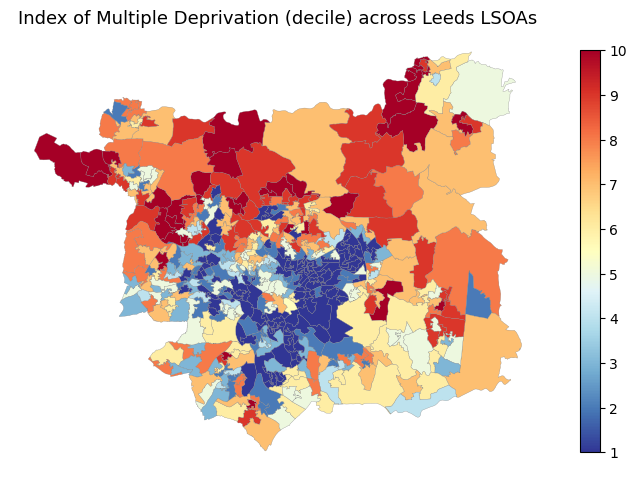

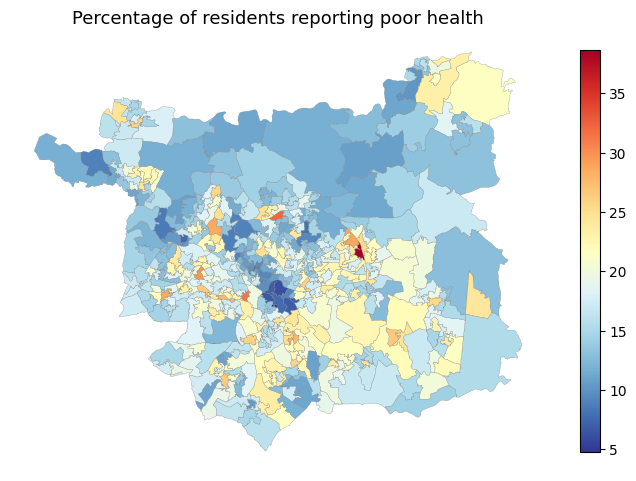

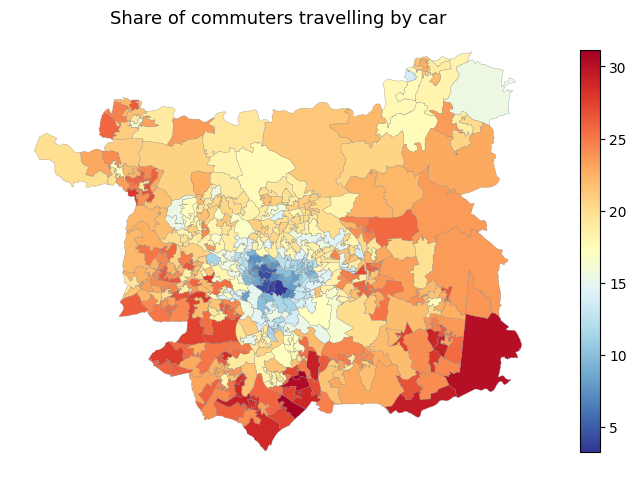

In [43]:
plot_map(gdf_leeds, "imd_decile", "Index of Multiple Deprivation (decile) across Leeds LSOAs")

plot_map(gdf_leeds, "poor_health_pct", "Percentage of residents reporting poor health")

plot_map(gdf_leeds, "car_pct", "Share of commuters travelling by car")


Local coefficient maps are presented for each explanatory variable to show how the direction and strength of associations vary across Leeds. This follows the standard exploratory use of GWR, where mapping local estimates is central for diagnosing spatial non-stationarity. :contentReference[oaicite:7]{index=7}

A local R² map is also presented to highlight where the model explains a larger or smaller share of variation in poor health, indicating that the selected predictors may perform better in some neighbourhood contexts than others.

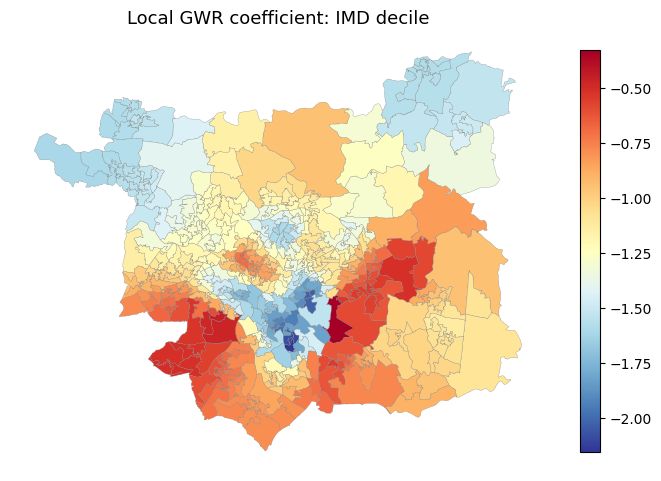

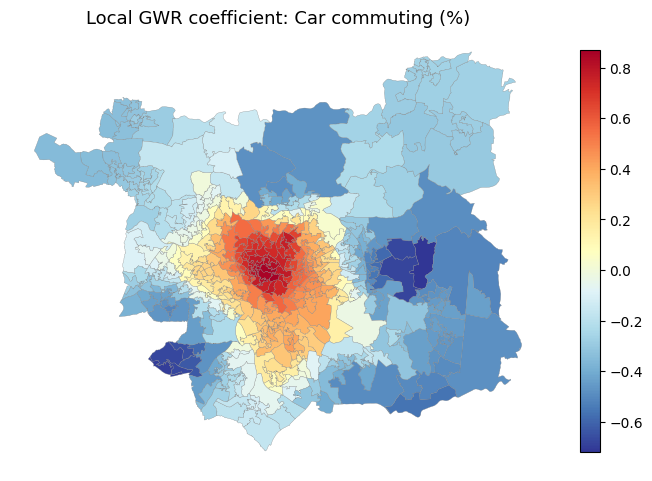

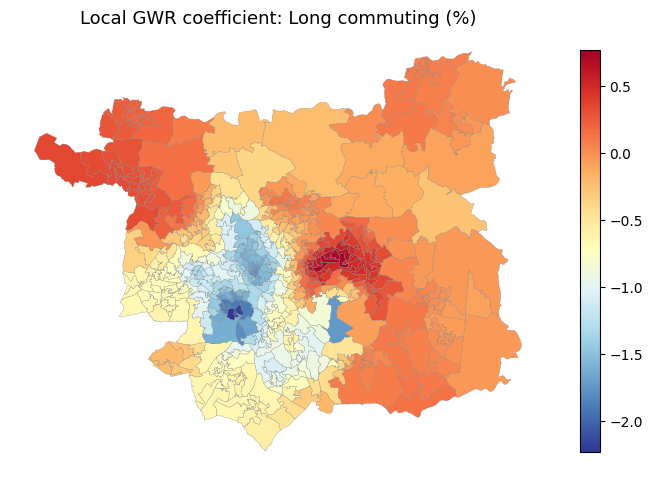

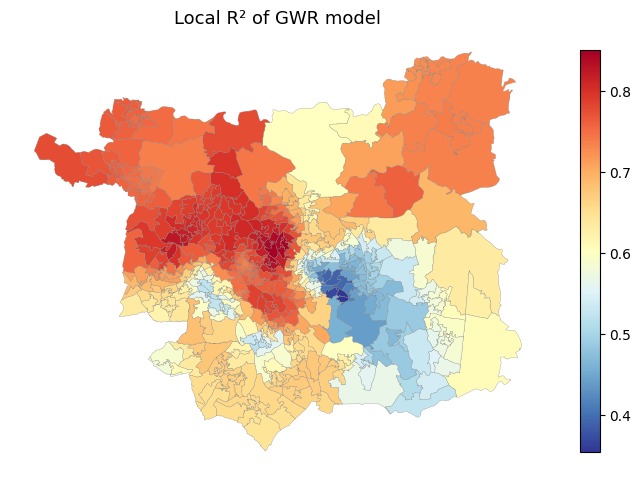

In [44]:
plot_map(df_gwr, "b_imd", "Local GWR coefficient: IMD decile")

plot_map(df_gwr, "b_car", "Local GWR coefficient: Car commuting (%)")

plot_map(df_gwr, "b_long", "Local GWR coefficient: Long commuting (%)")

plot_map(df_gwr, "localR2", "Local R² of GWR model")


# Discussion

This study demonstrates that poor health in Leeds is spatially clustered and strongly associated with area deprivation and commuting behaviour. Consistent with previous research, deprivation emerges as the dominant predictor of poor health, reinforcing evidence that socio-economic disadvantage plays a central role in shaping neighbourhood health outcomes (Sridharan et al., 2007; Bécares et al., 2012).

Car commuting is also positively associated with poor health, supporting findings that car dependence is linked to reduced physical activity and poorer wellbeing (Goodman et al., 2012). Importantly, GWR reveals that these relationships are not spatially uniform. The strength of deprivation and car commuting effects varies across Leeds, highlighting the presence of spatial non-stationarity.

These results illustrate the limitations of global regression approaches, which mask local variations in socio-health relationships. By allowing coefficients to vary spatially, GWR provides a more nuanced understanding of how deprivation and mobility interact with health in different neighbourhood contexts (Fotheringham et al., 2002).

From a policy perspective, the findings suggest that city-wide interventions alone may be insufficient. Place-based strategies targeting highly deprived and car-dependent areas may be more effective in reducing health inequalities.

# Conclusion

This study combines Census 2021 data, IMD indicators, and spatial modelling techniques to investigate neighbourhood health inequalities in Leeds. Results show significant spatial clustering of poor health and strong associations with deprivation and car commuting, with relationships varying substantially across space. By integrating Moran’s I, OLS and GWR, the analysis highlights the importance of spatially sensitive approaches for understanding urban health inequalities and supports the need for targeted, place-specific policy interventions.

# References
References (Leeds Harvard)

Bécares, L., Stafford, M., Nazroo, J. and Marmot, M. (2012) ‘Examining the differential association between self-rated health and area deprivation among white British and ethnic minority people in England’, Social Science & Medicine, 74(4), pp. 616–624.

Brunsdon, C., Fotheringham, A.S. and Charlton, M. (1998) ‘Geographically weighted regression: modelling spatial non-stationarity’, Journal of the Royal Statistical Society: Series D (The Statistician), 47(3), pp. 431–443.

Fotheringham, A.S., Brunsdon, C. and Charlton, M. (2002) Geographically weighted regression: the analysis of spatially varying relationships. Chichester: Wiley.

Goodman, A., Panter, J., Sharp, S.J. and Ogilvie, D. (2012) ‘Healthy travel and the socio-economic structure of car commuting in Cambridge, UK: a mixed-methods analysis’, Social Science & Medicine, 74(12), pp. 1929–1938.

Sridharan, S., Tunstall, H., Lawder, R. and Mitchell, R. (2007) ‘An exploratory spatial data analysis approach to understanding the relationship between deprivation and mortality in Scotland’, Social Science & Medicine, 65(9), pp. 1942–1952.

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-fr

In [49]:
!jupyter nbconvert \
  --to pdf \
  "/content/drive/MyDrive/Colab Notebooks/“GEOG5990M_Final_Project_template.ipynb”的副本"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/“GEOG5990M_Final_Project_template.ipynb”的副本 to pdf
[NbConvertApp] Support files will be in “GEOG5990M_Final_Project_template_files/
[NbConvertApp] Making directory ./“GEOG5990M_Final_Project_template_files
[NbConvertApp] Writing 132403 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1098707 bytes to /content/drive/MyDrive/Colab Notebooks/“GEOG5990M_Final_Project_template.pdf
